In [15]:
import pandas as pd
import numpy as np
from lifelines import CoxPHFitter, KaplanMeierFitter
from sklearn.linear_model import LogisticRegression
from sksurv.ensemble import RandomSurvivalForest

import warnings
warnings.simplefilter(action='ignore')

In [ ]:
data_cox = pd.read_csv('synthetic_data.csv')
data_cox.head()
print('Number of patients: %d' % data_cox.shape[0])
cols_basic = ['duration', 'event', 'fmi_test'] # Basic infomation for survival analysis
confounders = ['Female', 'Age >= 40', 'ECOG >= 3'] # Confounders
data_cox.head()

In [3]:
def process_HR(cph_summary, name_feature):
    '''
    Process result of CoxPH model to HR with 95% confidence intervals.
    '''
    result = cph_summary.loc[name_feature, ['exp(coef)', 'exp(coef) lower 95%', 'exp(coef) upper 95%']].values
    HR = '%.2f (%.2f, %.2f)' % tuple(result)   
    return HR
    
def Cox_IPTW(data_fit, name_feature):
    '''
    Uni-covariate CoxPH model with IPTW and left-truncation. 
    name_feature is the feature we are interested in (e.g., gene name or treatment name).
    Return the HR for name_feature.
    '''
    # Generate data used in Cox Regression with IPTW Weights
    data_confounders = data_fit.iloc[:, 3:].copy().drop(columns=[name_feature])
    df = pd.concat([data_fit.iloc[:, :3], data_fit[[name_feature]]], axis=1)
    X = data_confounders.values
    y = data_fit[name_feature].values
    model = LogisticRegression(solver='lbfgs', n_jobs=-1, class_weight='balanced')
    model.fit(X, y)
    p_treated = float(np.sum(y==1))/y.shape[0]
    propensity_scores = model.predict_proba(X)[:, 1]
    df['weights'] = 0
    IP_treated = 1 / propensity_scores
    IP_untreated = 1 / (1 - propensity_scores)        
    df.loc[df[name_feature]==1, 'weights'] = IP_treated[df[name_feature]==1]
    df.loc[df[name_feature]==0, 'weights'] = IP_untreated[df[name_feature]==0]    
    # Cox Regression
    cph = CoxPHFitter()
    cph.fit(df, 'duration', 'event', weights_col='weights', entry_col='fmi_test', robust=True)
    HR = process_HR(cph.summary, name_feature)
    return HR

In [4]:

data_fit = data_cox[cols_basic+confounders+['Gene A']]
HR = Cox_IPTW(data_fit, 'Gene A')
print('OS HR for Gene A: %s' % (HR))

OS HR for Gene A: 1.09 (1.01, 1.19)


In [5]:
gene = 'Gene A'
treatment = 'Treatment 1'

In [6]:
data_fit = data_cox[cols_basic+[gene, treatment]]
col_inter = '%s+%s'%(gene, treatment)
data_fit[col_inter] = data_fit[gene]*data_fit[treatment]
cph = CoxPHFitter()
cph.fit(data_fit, 'duration', 'event', entry_col='fmi_test', robust=True)
HR = process_HR(cph.summary, col_inter)
print('Interaction between Gene A and Treatment 1 is %s' % HR)

Interaction between Gene A and Treatment 1 is 0.65 (0.55, 0.77)


In [7]:
data_fit = data_cox.loc[data_cox[gene]==1, cols_basic+confounders+[treatment]].copy()
HR = Cox_IPTW(data_fit, treatment)
print('Treatment HR for patients with mutations of Gene A = %s' % HR)

data_fit = data_cox.loc[data_cox[gene]==0, cols_basic+confounders+[treatment]].copy()
HR = Cox_IPTW(data_fit, treatment)
print('Treatment HR for patients without mutations of Gene A = %s' % HR)

Treatment HR for patients with mutations of Gene A = 0.79 (0.69, 0.89)
Treatment HR for patients without mutations of Gene A = 1.20 (1.08, 1.34)


In [8]:
data_fit = data_cox.loc[data_cox[treatment]==1, cols_basic+confounders+[gene]].copy()
HR = Cox_IPTW(data_fit, gene)
print('Gene A mutation HR for patients who received Treatment 1 = %s' % HR)

data_fit = data_cox.loc[data_cox[treatment]==0, cols_basic+confounders+[gene]].copy()
HR = Cox_IPTW(data_fit, gene)
print('Gene A mutation HR for patients who didn\'t receive Treatment 1 = %s' % HR)

Gene A mutation HR for patients who received Treatment 1 = 0.90 (0.81, 1.01)
Gene A mutation HR for patients who didn't receive Treatment 1 = 1.41 (1.24, 1.60)


In [9]:
gene_anchor = 'Gene A'
gene_modifier = 'Gene B' 
data_fit = data_cox.loc[data_cox[gene_anchor]==1, cols_basic+confounders+[gene_modifier]]
HR = Cox_IPTW(data_fit, gene_modifier)
print('modifier gene HR for anchor gene positive: %s' % HR)

modifier gene HR for anchor gene positive: 0.85 (0.75, 0.97)


In [10]:
## Adding Survival Curves

In [16]:
def generate_RSF_data(data_cox, genes):
    '''
    Transform the data into the form to feed into the random survival forest:
        X: mutation status profile (genes)
        y: survival outcome
    '''
    # We predict the survival time only from the mutation status
    X = data_cox[genes].values
    y = [] 
    for idx in data_cox.index:
        event = True if data_cox.loc[idx, 'event']==1 else False
        y.append((event, data_cox.loc[idx, 'duration']))
    y = np.array(y, dtype=[('cens', '?'), ('time', '<f8')])
    y = np.array(y)
    return X, y


def fit_RSF(data_cox, genes):
    '''
    Fit RSF model to predict survival time from the mutation status of genes.
    '''
    X, y = generate_RSF_data(data_cox, genes)
    rsf = RandomSurvivalForest(n_estimators=20,
                               min_samples_split=10,
                               min_samples_leaf=15, 
                               max_features="sqrt",
                               n_jobs=-1,
                               random_state=1001)
    rsf.fit(X, y)
    return rsf

def predict_RSF(data_cox, genes, rsf):
    '''
    Retrieve the predicted survival time, given mutation status of genes and RSF model rsf.
    '''
    X, y = generate_RSF_data(data_cox, genes)
    return rsf.predict(X)


treatment = 'Treatment 1'
# genes = ['Gene A', 'Gene B', 'Gene C', 'Gene D', 'Gene E']
genes = ['Gene A', 'Gene B']
# Train-test split
train_size = 0.7
np.random.seed(1001)
index_train = np.random.choice(data_cox.index, int(train_size*data_cox.shape[0]), replace=False)
data_fit_train = data_cox.loc[index_train].copy()
data_fit_test = data_cox.loc[~data_cox.index.isin(index_train)].copy()

# Fit RSF model
rsf_treatment = fit_RSF(data_fit_train.loc[data_fit_train[treatment]==1], genes)
rsf_nontreatment = fit_RSF(data_fit_train.loc[data_fit_train[treatment]==0], genes)

# On test data, compute the survival time
time_treatment = predict_RSF(data_fit_test, genes, rsf_treatment)
time_nontreatment = predict_RSF(data_fit_test, genes, rsf_nontreatment)

# Compute the binary RSF score
data_fit_test['RSF Score'] = (time_treatment < time_nontreatment).astype(int)

data_fit_test.head()

,Female,Age >= 40,ECOG >= 3,Gene A,Gene B,Treatment 1,Treatment 2,duration,event,fmi_test,RSF Score
2,1,1,1,1,1,0,1,132,1,31,1
3,0,0,0,0,0,0,1,62,1,28,0
4,0,0,0,0,0,0,1,46,1,32,0
7,0,1,1,1,0,0,1,59,1,6,1
10,1,0,0,0,0,0,1,457,1,6,0


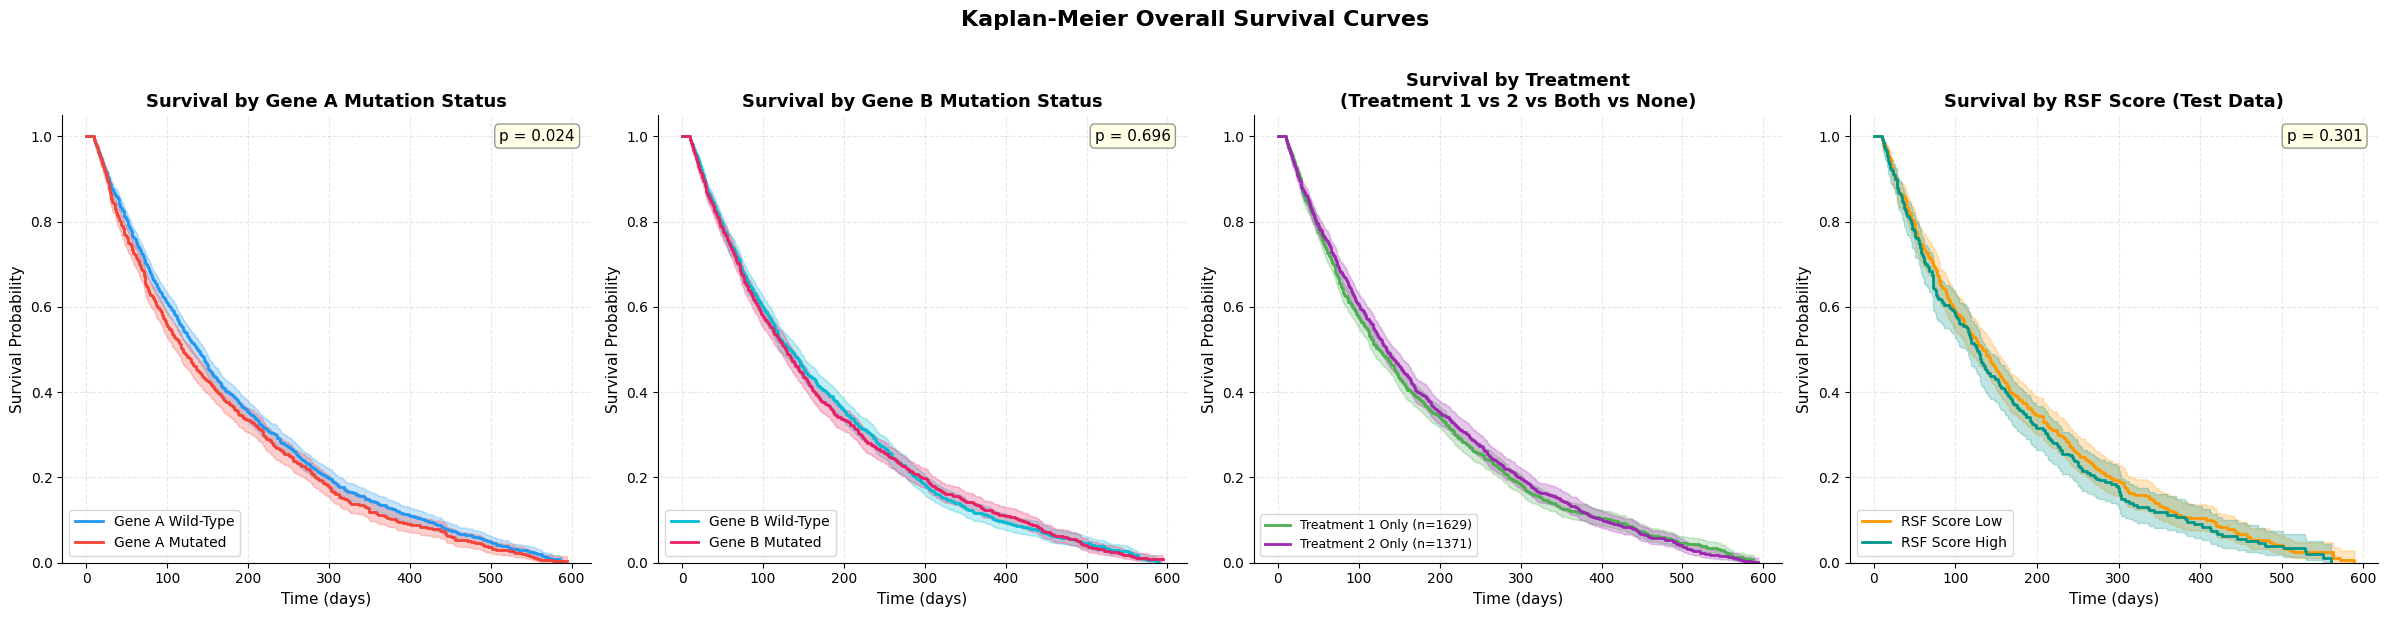

Kaplan-Meier curves saved to km_survival_curves.png


In [17]:
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test


data_fit_test['RSF Score'] = (time_treatment < time_nontreatment).astype(int)

fig, axes = plt.subplots(1, 4, figsize=(24, 6))

fig.suptitle('Kaplan-Meier Overall Survival Curves', fontsize=16, fontweight='bold', y=1.02)

def plot_km(ax, data, group_col, group_labels, title, colors=None):
    if colors is None:
        colors = ['#2196F3', '#F44336']
        
    kmf = KaplanMeierFitter()
    groups = sorted(data[group_col].unique())

    
    for i, grp in enumerate(groups):
        mask = data[group_col] == grp
        kmf.fit(data.loc[mask, 'duration'], data.loc[mask, 'event'], label=group_labels[i])
        kmf.plot_survival_function(ax=ax, ci_show=True, color=colors[i], linewidth=2)

        
    g0 = data[group_col] == groups[0]
    g1 = data[group_col] == groups[1]
    res = logrank_test(data.loc[g0, 'duration'], data.loc[g1, 'duration'],
                       event_observed_A=data.loc[g0, 'event'],
                       event_observed_B=data.loc[g1, 'event'])
    p = res.p_value
    p_text = f'p = {p:.3f}' if p >= 0.001 else 'p < 0.001'

    
    ax.text(0.97, 0.97, p_text, transform=ax.transAxes,
            ha='right', va='top', fontsize=11,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray', alpha=0.8))
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Time (days)', fontsize=11)
    ax.set_ylabel('Survival Probability', fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=10, loc='lower left')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Gene A Plot
plot_km(axes[0], data_cox, 'Gene A', ['Gene A Wild-Type', 'Gene A Mutated'], 'Survival by Gene A Mutation Status',
                colors=['#2196F3', '#F44336'])



# Gene B Plot
plot_km(axes[1], data_cox, 'Gene B',
        ['Gene B Wild-Type', 'Gene B Mutated'], 'Survival by Gene B Mutation Status',
        colors=['#00BCD4', '#E91E63'])



# Plot 3 treatment 1 vs treatment 2 vs Neither on the same axes
def get_treatment_group(row):
    t1, t2 = row['Treatment 1'], row['Treatment 2']
    if t1 == 1 and t2 == 1:
        return 'Both Treatments'
    elif t1 == 1:
        return 'Treatment 1 Only'
    elif t2 == 1:
        return 'Treatment 2 Only'
    else:
        return 'No Treatment'



data_cox['Treatment Group'] = data_cox.apply(get_treatment_group, axis=1)
kmf = KaplanMeierFitter()
group_colors = {
    'No Treatment':      '#9E9E9E',
    'Treatment 1 Only':  '#4CAF50',
    'Treatment 2 Only':  '#9C27B0',
    'Both Treatments':   '#FF5722',
}


ax3 = axes[2]
for label, color in group_colors.items():
    mask = data_cox['Treatment Group'] == label
    if mask.sum() > 0:
        kmf.fit(data_cox.loc[mask, 'duration'], data_cox.loc[mask, 'event'], label=f'{label} (n={mask.sum()})')
        kmf.plot_survival_function(ax=ax3, ci_show=True, color=color, linewidth=2)
ax3.set_title('Survival by Treatment\n(Treatment 1 vs 2 vs Both vs None)', fontsize=13, fontweight='bold')
ax3.set_xlabel('Time (days)', fontsize=11)
ax3.set_ylabel('Survival Probability', fontsize=11)
ax3.set_ylim(0, 1.05)
ax3.legend(fontsize=9, loc='lower left')
ax3.grid(True, alpha=0.3, linestyle='--')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)




# Plot 4 for RFS
plot_km(axes[3], data_fit_test, 'RSF Score', ['RSF Score Low', 'RSF Score High'], 'Survival by RSF Score (Test Data)',
                                            colors=['#FF9800', '#009688'])

plt.tight_layout()

plt.savefig('km_survival_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Kaplan-Meier curves saved to km_survival_curves.png')
